# HF TDOA vs Ionosonde Comparison - Figure 13

This notebook creates Figure 13 showing a comprehensive 3x3 grid comparison of:
- **3 Analysis Methods (rows):**
  1. Beat Note Period Analysis (Manual)
  2. Autocorrelation Analysis (Manual)
  3. Beat Note Automated FFT Analysis (2F2-1F2)

- **3 Propagation Paths (columns):**
  1. NVIS Path AB5YO 7.2 MHz (7.2 MHz)
  2. NVIS Path AB5YO 5.3 MHz (5.3 MHz)
  3. 317 km Path N5DUP 7.2 MHz (7.2 MHz)

Each subplot shows:
- Scatter plot of TDOA height vs Austin Ionosonde hmF2
- Linear regression line with equation
- Statistics box with correlation (r), RMSE, and Bias

In [1]:
import os
import pandas as pd
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load Austin Ionosonde Data

Load the manually-scaled Austin TX ionosonde data to use as reference values for hmF2.

In [2]:
# Load ionosonde data
ionosonde_csv = '../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv'
ionosonde_df = tdoa.load_ionosonde_data(ionosonde_csv)

print(f"Ionosonde data loaded: {len(ionosonde_df)} records")
print(f"Time range: {ionosonde_df.index[0]} to {ionosonde_df.index[-1]}")
print(f"\nFirst few records:")
print(ionosonde_df[['hmF2']].head())

Ionosonde data loaded: 288 records
Time range: 2024-04-08 00:00:05 to 2024-04-08 23:55:05

First few records:
                      hmF2
UTC                       
2024-04-08 00:00:05  286.5
2024-04-08 00:05:05  296.1
2024-04-08 00:10:05  282.9
2024-04-08 00:15:05  286.6
2024-04-08 00:20:05  286.7


## Load TDOA Datasets

Load all TDOA datasets for the 3x3 grid:
- Manual period analysis (row 1)
- Manual autocorrelation analysis (row 2)  
- Automated FFT analysis (row 3)

For each of the three paths:
- AB5YO 7.2 MHz (7.2 MHz) - NVIS path
- AB5YO 5.3 MHz (5.3 MHz) - NVIS path
- N5DUP 7.2 MHz (7.2 MHz) - 317 km path

In [3]:
# Define the 3x3 grid of datasets
# Structure: datasets[row][column] where:
#   row 0 = Manual Period Analysis
#   row 1 = Autocorrelation Analysis
#   row 2 = Automated FFT Analysis (2F2-1F2)
#   col 0 = AB5YO 7.2 MHz (7.2 MHz)
#   col 1 = AB5YO 5.3 MHz (5.3 MHz)
#   col 2 = N5DUP 7.2 MHz (7.2 MHz)

datasets_grid = []

# Row 1: Manual Period Analysis
row_period = []

# AB5YO 7.2 MHz - Manual Period
ab5yo_40m_period = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_period_analysis.csv'
)
row_period.append({
    'df': ab5yo_40m_period,
    'label': 'AB5YO 7.2 MHz (Manual Period)',
    'color': '#ff7f0e',  # orange
    'marker': '^'
})

# AB5YO 5.3 MHz - Manual Period
ab5yo_60m_period = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_manual_period_analysis.csv'
)
row_period.append({
    'df': ab5yo_60m_period,
    'label': 'AB5YO 5.3 MHz (Manual Period)',
    'color': '#2ca02c',  # green
    'marker': '^'
})

# N5DUP 7.2 MHz - Manual Period
n5dup_40m_period = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m_manual_period_analysis.csv'
)
row_period.append({
    'df': n5dup_40m_period,
    'label': 'N5DUP 7.2 MHz (Manual Period)',
    'color': '#1f77b4',  # blue
    'marker': '^'
})

datasets_grid.append(row_period)

# Row 2: Autocorrelation Analysis
row_autocorr = []

# AB5YO 7.2 MHz - Autocorrelation
ab5yo_40m_autocorr = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_autocorrelation_analysis.csv'
)
row_autocorr.append({
    'df': ab5yo_40m_autocorr,
    'label': 'AB5YO 7.2 MHz (Autocorrelation)',
    'color': '#ff7f0e',  # orange
    'marker': 'v'
})

# AB5YO 5.3 MHz - Autocorrelation
ab5yo_60m_autocorr = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_autocorrelation_analysis.csv'
)
row_autocorr.append({
    'df': ab5yo_60m_autocorr,
    'label': 'AB5YO 5.3 MHz (Autocorrelation)',
    'color': '#2ca02c',  # green
    'marker': 'v'
})

# N5DUP 7.2 MHz - Autocorrelation
n5dup_40m_autocorr = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m_autocorrelation_analysis.csv'
)
row_autocorr.append({
    'df': n5dup_40m_autocorr,
    'label': 'N5DUP 7.2 MHz (Autocorrelation)',
    'color': '#1f77b4',  # blue
    'marker': 'v'
})

datasets_grid.append(row_autocorr)

# Row 3: Automated FFT Analysis (2F2-1F2)
row_automated = []

# AB5YO 7.2 MHz - Automated (2F2-1F2)
auto_ab5yo_40m = tdoa.TDOAData(
    '../fig_12/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m.csv'
)
row_automated.append({
    'df': auto_ab5yo_40m.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'AB5YO 7.2 MHz (2F2-1F2)',
    'color': '#ff7f0e',  # orange
    'marker': 'o'
})

# AB5YO 5.3 MHz - Automated (2F2-1F2)
auto_ab5yo_60m = tdoa.TDOAData(
    '../fig_12/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m.csv'
)
row_automated.append({
    'df': auto_ab5yo_60m.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'AB5YO 5.3 MHz (2F2-1F2)',
    'color': '#2ca02c',  # green
    'marker': 'o'
})

# N5DUP 7.2 MHz - Automated (2F2-1F2)
auto_n5dup_40m = tdoa.TDOAData(
    '../fig_11/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m.csv'
)
row_automated.append({
    'df': auto_n5dup_40m.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'N5DUP 7.2 MHz (2F2-1F2)',
    'color': '#1f77b4',  # blue
    'marker': 'o'
})

datasets_grid.append(row_automated)

# Print summary
print("Loaded datasets for 3x3 grid:")
row_labels = ['Beat Note Period Analysis', 'Autocorrelation Analysis', 'Beat Note Automated FFT Analysis']
col_labels = ['AB5YO 7.2 MHz (7.2 MHz)', 'AB5YO 5.3 MHz (5.3 MHz)', 'N5DUP 7.2 MHz (7.2 MHz)']

for row_idx, (row, row_label) in enumerate(zip(datasets_grid, row_labels)):
    print(f"\n{row_label}:")
    for col_idx, (dataset, col_label) in enumerate(zip(row, col_labels)):
        print(f"  [{row_idx},{col_idx}] {col_label}: {len(dataset['df'])} points")

Loaded datasets for 3x3 grid:

Beat Note Period Analysis:
  [0,0] AB5YO 40m (7.2 MHz): 47 points
  [0,1] AB5YO 60m (5.3 MHz): 39 points
  [0,2] N5DUP 40m (7.2 MHz): 47 points

Autocorrelation Analysis:
  [1,0] AB5YO 40m (7.2 MHz): 35 points
  [1,1] AB5YO 60m (5.3 MHz): 38 points
  [1,2] N5DUP 40m (7.2 MHz): 25 points

Beat Note Automated FFT Analysis:
  [2,0] AB5YO 40m (7.2 MHz): 49 points
  [2,1] AB5YO 60m (5.3 MHz): 39 points
  [2,2] N5DUP 40m (7.2 MHz): 32 points


## Statistical Measures

Each subplot in Figure 13 displays four key statistical measures comparing TDOA-derived heights with ionosonde hmF2 values:

### 1. Sample Size (n)
**Definition:** The number of data points where both TDOA measurements and ionosonde hmF2 values are available at matching times.

**Calculation:**
```
n = count of valid paired measurements
```

**Interpretation:** Larger sample sizes (n > 30) generally provide more statistically reliable results.

### 2. Pearson Correlation Coefficient (r)
**Definition:** Measures the strength and direction of the linear relationship between TDOA heights and ionosonde hmF2.

**Calculation:**
```
r = Σ[(xi - x̄)(yi - ȳ)] / √[Σ(xi - x̄)² · Σ(yi - ȳ)²]
```
where:
- xi = ionosonde hmF2 values
- yi = TDOA height values
- x̄, ȳ = respective means

**Range:** -1.0 to +1.0

**Interpretation:**
- r = +1.0: Perfect positive linear correlation
- r = 0.0: No linear correlation
- r = -1.0: Perfect negative linear correlation
- |r| > 0.9: Very strong correlation
- |r| > 0.7: Strong correlation
- |r| > 0.5: Moderate correlation

### 3. Root Mean Square Error (RMSE)
**Definition:** Measures the average magnitude of errors between TDOA heights and ionosonde hmF2, giving more weight to larger errors.

**Calculation:**
```
RMSE = √[Σ(yi - xi)² / n]
```
where:
- yi = TDOA height values
- xi = ionosonde hmF2 values (reference)
- n = number of data points

**Units:** Kilometers (km)

**Interpretation:**
- RMSE = 0: Perfect agreement (no error)
- Lower RMSE indicates better accuracy
- Sensitive to outliers due to squaring
- Typical ionospheric F2 layer: RMSE < 30 km is good agreement

### 4. Bias (Mean Error)
**Definition:** Measures the systematic offset (average difference) between TDOA heights and ionosonde hmF2.

**Calculation:**
```
Bias = Σ(yi - xi) / n = ȳ - x̄
```
where:
- yi = TDOA height values
- xi = ionosonde hmF2 values (reference)
- n = number of data points

**Units:** Kilometers (km)

**Interpretation:**
- Bias = 0: No systematic offset
- Bias > 0: TDOA systematically overestimates height
- Bias < 0: TDOA systematically underestimates height
- Can be corrected by applying a constant offset

### Statistical Note

**Origin Point (0,0):** When `include_origin=True` is specified (as in this analysis), the point (0,0) is included in the calculation of the regression line and statistics. This forces the regression through the origin and can affect the correlation coefficient and other statistics. This approach assumes that zero TDOA corresponds to zero height difference, which may or may not be physically meaningful depending on the propagation mode analysis.

**Relationship between metrics:**
- RMSE² = Bias² + Variance
- A dataset can have low bias but high RMSE (random scatter)
- A dataset can have high bias but low RMSE (systematic offset)
- Ideal result: high r, low RMSE, and low bias

## Create 3x3 Grid Figure

Create the comprehensive 3x3 grid figure showing all analysis methods across all paths.

**Grid Layout:**
- **Rows (Analysis Methods):**
  1. Beat Note Period Analysis (Manual)
  2. Autocorrelation Analysis (Manual)
  3. Beat Note Automated FFT Analysis (2F2-1F2)

- **Columns (Propagation Paths):**
  1. NVIS Path AB5YO 7.2 MHz (7.2 MHz)
  2. NVIS Path AB5YO 5.3 MHz (5.3 MHz)
  3. 317 km Path N5DUP 7.2 MHz (7.2 MHz)

Each subplot includes:
- Scatter plot with appropriate markers and colors
- Linear regression line with equation
- Statistics box showing correlation (r), RMSE, and Bias

Creating 3x3 scatter plot grid figure...

Saved: fig_14.jpg

Figure 14 saved to: fig_14.jpg

STATISTICS SUMMARY

Beat Note Period Analysis:
Path                           n        r       RMSE       Bias
------------------------------------------------------------
NVIS Path AB5YO 7.2 MHz       47    0.944      14.8 km       2.2 km
NVIS Path AB5YO 5.3 MHz       39    0.942      26.6 km     -21.3 km
317 km Path N5DUP 7.2 MHz     33    0.952      20.5 km      12.5 km

Autocorrelation Analysis:
Path                           n        r       RMSE       Bias
------------------------------------------------------------
NVIS Path AB5YO 7.2 MHz       35    0.940      17.3 km      -3.6 km
NVIS Path AB5YO 5.3 MHz       38    0.913      27.0 km     -18.2 km
317 km Path N5DUP 7.2 MHz     25    0.934      26.5 km      14.6 km

Beat Note Automated FFT Analysis:
Path                           n        r       RMSE       Bias
------------------------------------------------------------
NVIS Path AB5YO

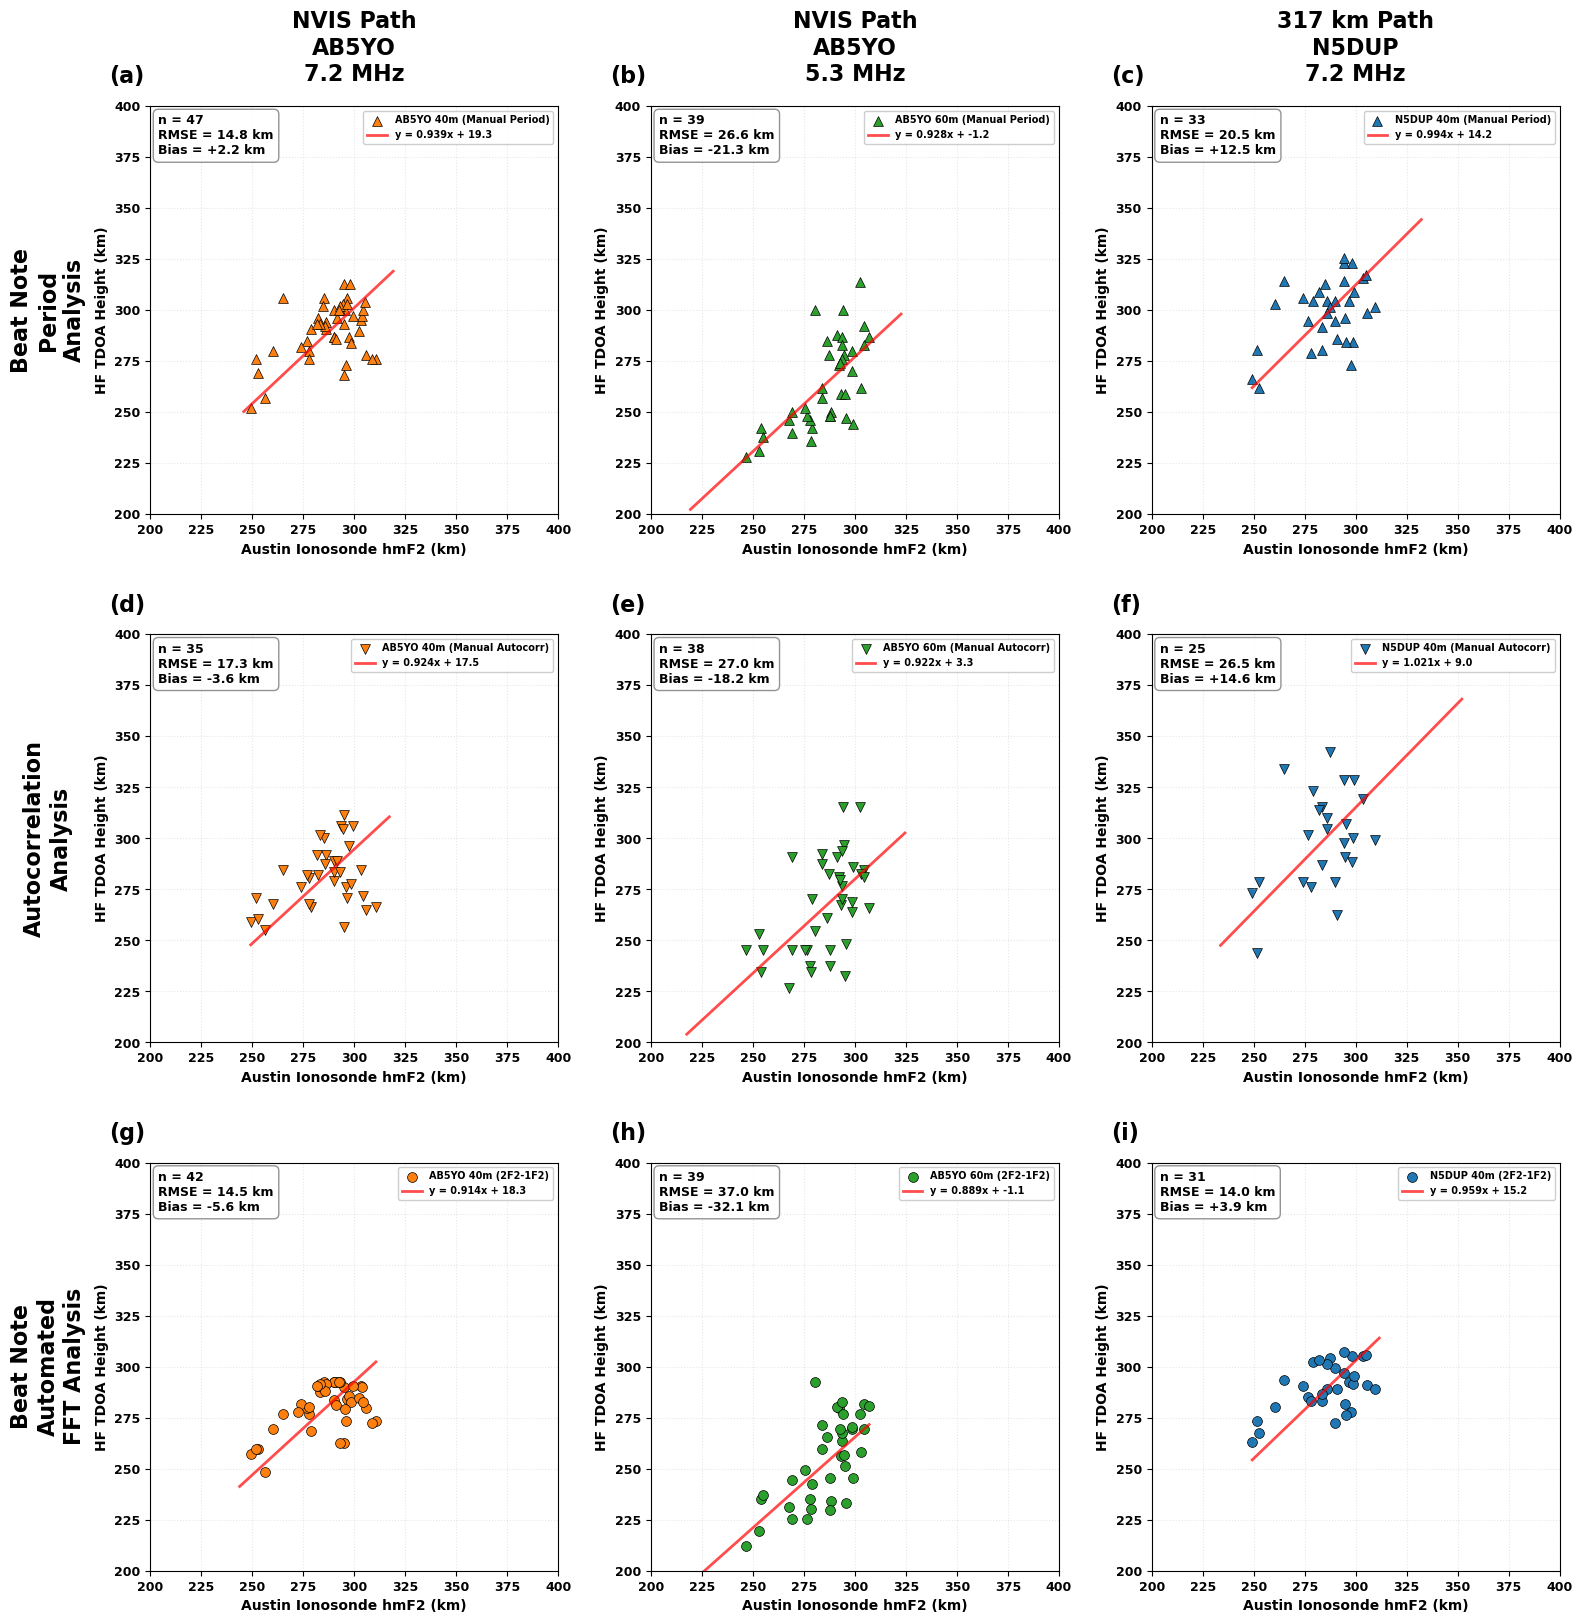

In [4]:
# Create the 3x3 grid figure
print("Creating 3x3 scatter plot grid figure...\n")

# Define row and column labels
row_labels = ['Beat Note\nPeriod\nAnalysis', 'Autocorrelation\nAnalysis', 'Beat Note\nAutomated\nFFT Analysis']
col_titles = [
    'NVIS Path\nAB5YO\n7.2 MHz',
    'NVIS Path\nAB5YO\n5.3 MHz',
    '317 km Path\nN5DUP\n7.2 MHz'
]

# Create the figure
results = tdoa.create_3x3_scatter_grid(
    datasets_grid,
    ionosonde_df,
    row_labels=row_labels,
    col_titles=col_titles,
    filepath='fig_13.jpg',
    include_origin=True,
    show_regression=True
)

print("\nFigure 14 saved to: fig_13.jpg")

# Print statistics summary
print("\n" + "="*90)
print("STATISTICS SUMMARY")
print("="*90)

for row_idx, row_label in enumerate(row_labels):
    print(f"\n{row_label.replace(chr(10), ' ')}:")
    print(f"{'Path':<25s} {'n':>6s} {'r':>8s} {'RMSE':>10s} {'Bias':>10s}")
    print("-"*60)
    
    for col_idx, col_title in enumerate(col_titles):
        stats = results[row_idx][col_idx]
        path_name = col_title.replace('\n', ' ')
        if stats and 'n_points' in stats:
            print(f"{path_name:<25s} {stats['n_points']:6d} {stats['correlation']:8.3f} "
                  f"{stats['rmse']:9.1f} km {stats['bias']:9.1f} km")
        else:
            print(f"{path_name:<25s} {'N/A':>6s} {'N/A':>8s} {'N/A':>10s} {'N/A':>10s}")

print("="*90)

## Summary

This notebook creates Figure 13, a comprehensive 3x3 grid comparison of HF TDOA height measurements with Austin Ionosonde hmF2 values.

### Key Features:

**Analysis Methods Compared (Rows):**
1. Beat Note Period Analysis - Manual measurement of chirp repetition period
2. Autocorrelation Analysis - Automated detection using autocorrelation
3. Beat Note Automated FFT Analysis - Fully automated FFT-based detection (2F2-1F2 mode)

**Propagation Paths Compared (Columns):**
1. NVIS Path AB5YO 7.2 MHz (40m band) - Short range NVIS propagation
2. NVIS Path AB5YO 5.3 MHz (60m band) - Lower frequency NVIS propagation
3. 317 km Path N5DUP 7.2 MHz (40m band) - Longer distance propagation

**Statistical Metrics:**
- **n**: Number of matched data points with ionosonde measurements
- **r**: Correlation coefficient (closer to 1.0 indicates better linear agreement)
- **RMSE**: Root mean square error in kilometers
- **Bias**: Systematic offset in kilometers (positive = TDOA overestimates height)

### Interpretation:

This comprehensive comparison enables evaluation of:
- Consistency between manual and automated analysis methods
- Impact of frequency on measurement accuracy (7.2 MHz vs 5.3 MHz)
- Performance across different propagation distances (NVIS vs 317 km)
- Overall accuracy of TDOA-based ionospheric height estimation

The visual presentation allows direct comparison of all combinations of analysis methods and propagation paths, making it easy to identify which techniques work best under which conditions.